<h1 style="text-align:center;">Análise Exploratória de Dados (EDA) – Base de Artigos</h1>

### 1. Carregando a base de Dados

In [2]:
import pandas as pd

df = pd.read_csv('../data/articles.csv')

### 2. Quantidade de linhas para serem analisadas

In [3]:
# mostra a quantidade de linhas e colunas do DataFrame
df.shape

(167053, 6)

### 3. Identificando valores nulos na coluna text

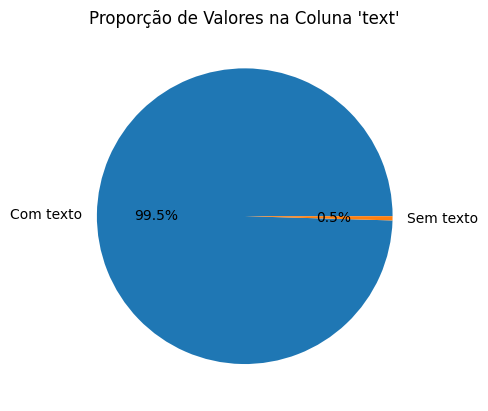

In [4]:
import matplotlib.pyplot as plt

# Calcula a porcentagem de valores nulos na coluna 'text'
total_linhas = len(df)
textos_nulo = df['text'].isnull().sum()
porcentagem_texto_nulo = (textos_nulo / total_linhas) * 100
porcentagem_texto_não_nulo = 100 - porcentagem_texto_nulo


plt.figure()
plt.pie(
    [porcentagem_texto_não_nulo, porcentagem_texto_nulo],
    labels=['Com texto', 'Sem texto'],
    autopct='%1.1f%%'
)

plt.title("Proporção de Valores na Coluna 'text'")
plt.show()

### 4. Verificando o tipo de dados de cada coluna

In [5]:
df = df.dropna(subset=['text']) # remove as linhas onde a coluna 'text' tem valores nulos

df.dtypes # mostra os tipos de dados de cada coluna do DataFrame


title          str
text           str
date           str
category       str
subcategory    str
link           str
dtype: object

In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce') # converte a coluna 'date' para o tipo datetime, tratando erros

df.describe() # mostra estatísticas descritivas para as colunas numéricas do DataFrame

,date
count,166288
mean,2016-03-25 16:46:23.046281
min,2015-01-01 00:00:00
25%,2015-07-24 00:00:00
50%,2016-03-03 00:00:00
75%,2016-11-08 00:00:00
max,2017-10-01 00:00:00


### 5. Analisando a coluna category

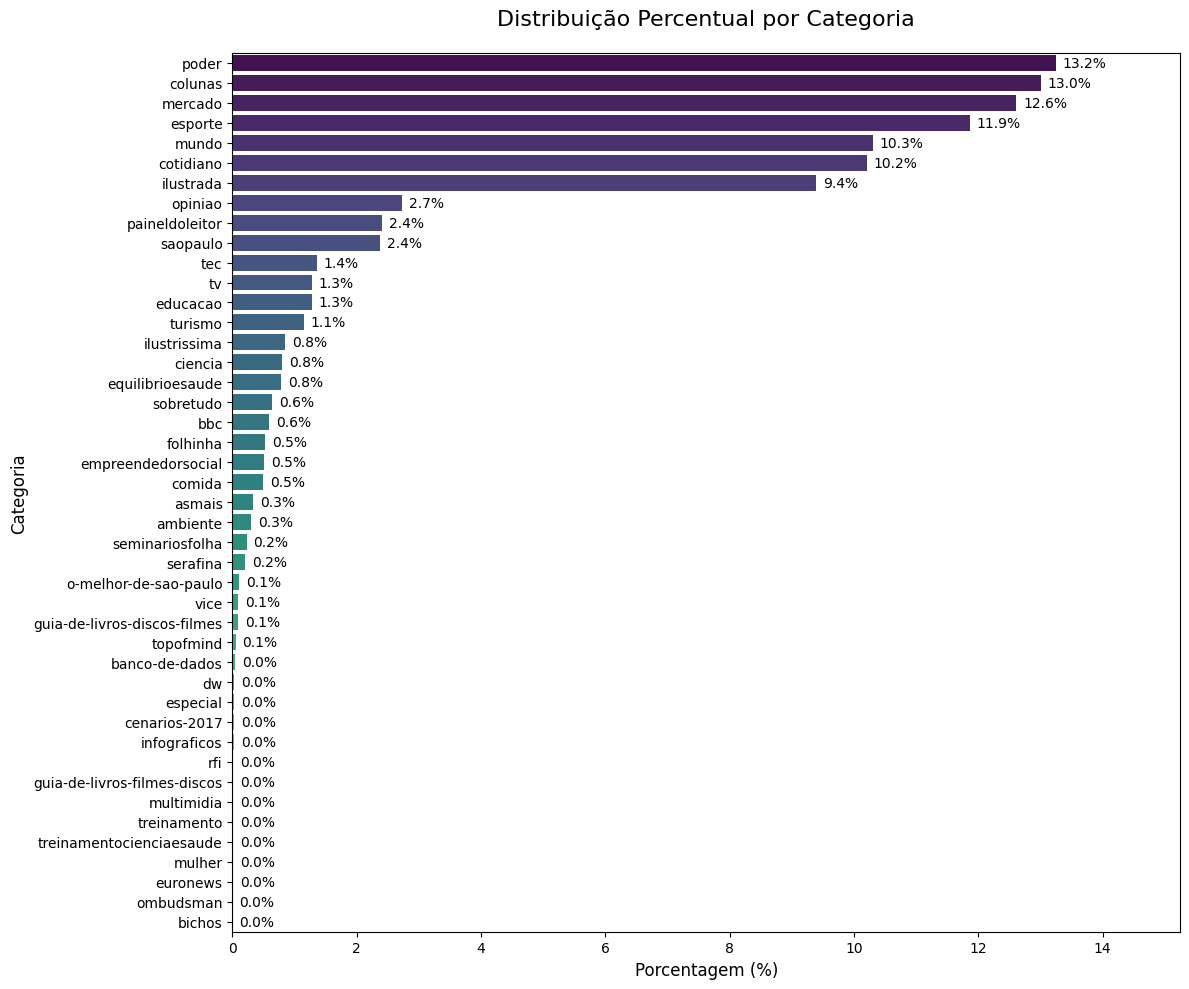

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.container import BarContainer

# 1. Calculando as porcentagens
total = len(df)
contagem = df['category'].value_counts().reset_index()
contagem.columns = ['category', 'quantidade']
contagem['porcentagem'] = (contagem['quantidade'] / total) * 100

# 2. Criando o gráfico
plt.figure(figsize=(12, 10))
ax = sns.barplot(
    data=contagem,
    y='category',
    x='porcentagem',
    hue='category',
    palette='viridis',
    legend=False
)

# 3. Adicionando os rótulos de porcentagem ao final de cada barra
for i in ax.containers:
    if isinstance(i, BarContainer):
        ax.bar_label(i, fmt='%.1f%%', padding=5)

# Configurações visuais
plt.title('Distribuição Percentual por Categoria', fontsize=16, pad=20)
plt.xlabel('Porcentagem (%)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.xlim(0, contagem['porcentagem'].max() + 2) # Dá um espaço extra para o texto não sumir

plt.tight_layout()
plt.show()

### 6. Analisando comprimento dos títulos

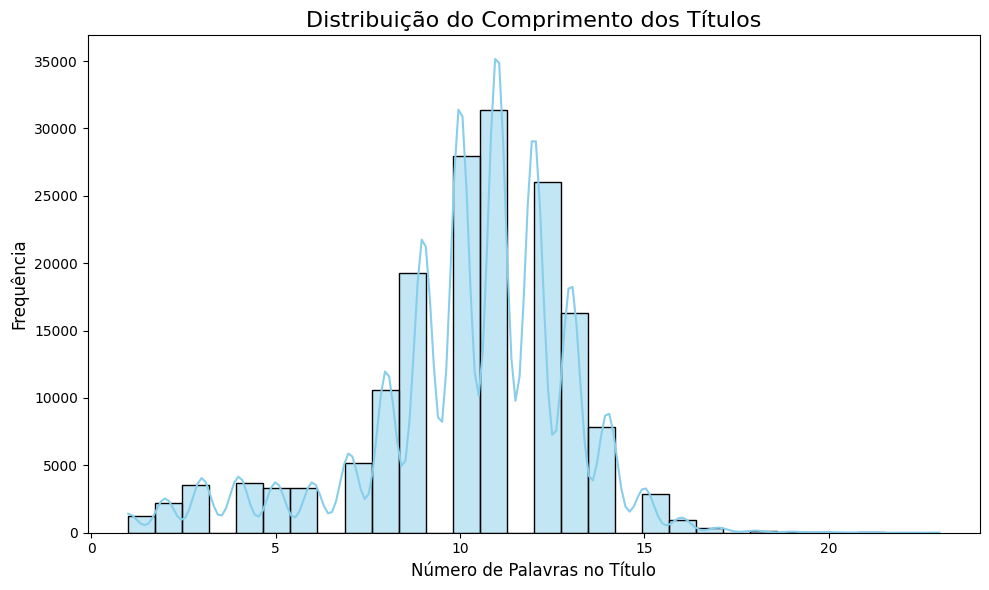

In [8]:
df['title_len'] = df['title'].apply(lambda x: len(str(x).split())) # cria uma nova coluna 'title_len' com o comprimento de cada título
plt.figure(figsize=(10, 6))
sns.histplot(df['title_len'], bins=30, kde=True, color='skyblue')
plt.title('Distribuição do Comprimento dos Títulos', fontsize=16)
plt.xlabel('Número de Palavras no Título', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.tight_layout()
plt.show()

### 7. Análise do Títulos das Top 5 categorias (Bigramas)

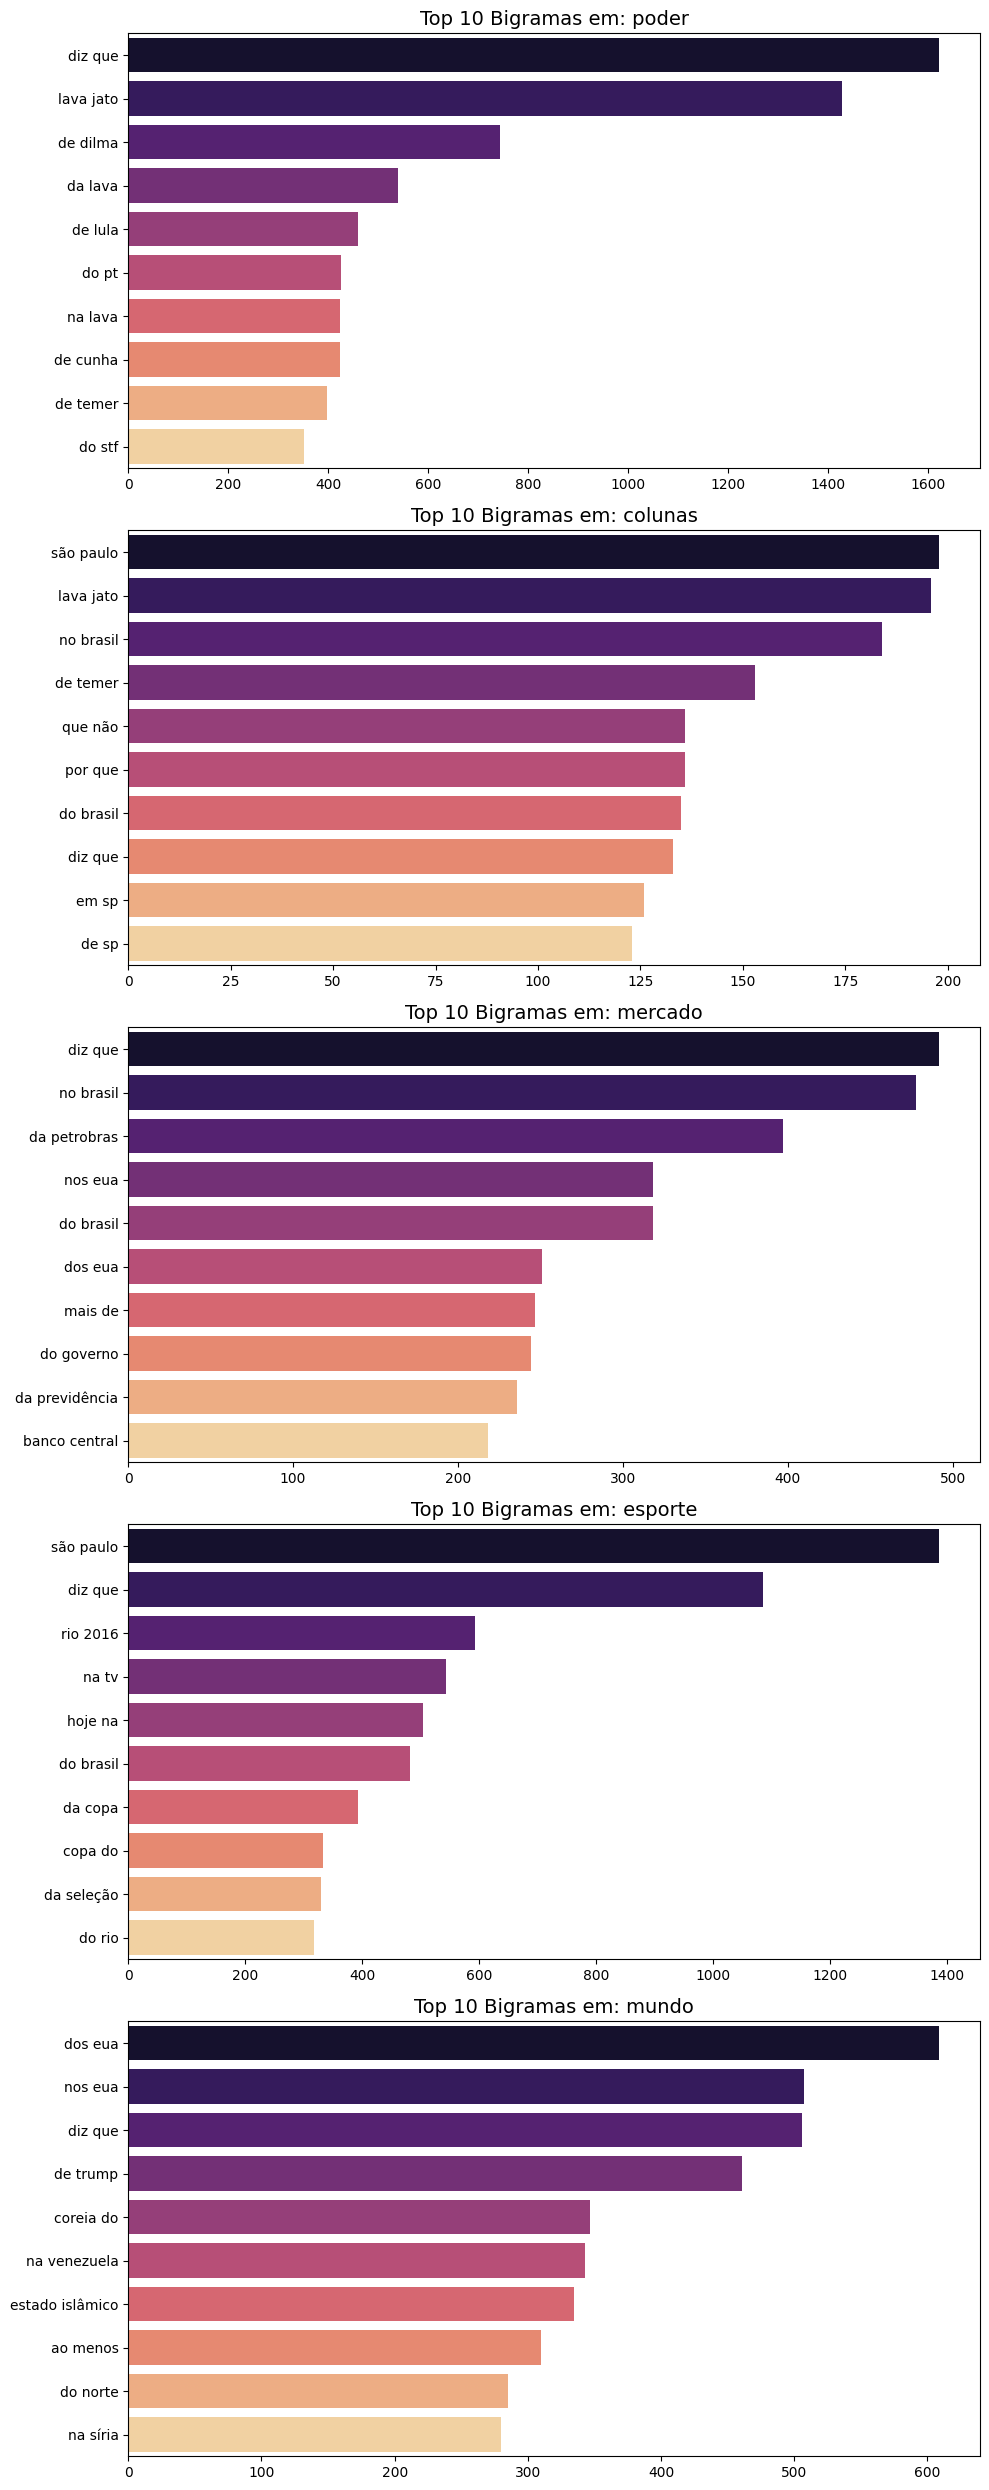

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

# Filtrando as 5 principais caregorias
top_categorias = df['category'].value_counts().nlargest(5).index

_, axes = plt.subplots(5, 1, figsize=(10, 25))

for i, categoria in enumerate(top_categorias):
  categoria_titulos = df[df['category'] == categoria]['title']

  cv = CountVectorizer(ngram_range=(2, 2), max_features=10)
  bag_of_words = cv.fit_transform(categoria_titulos)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  words, counts = zip(*words_freq)
  sns.barplot(x=list(counts), y=list(words), ax=axes[i], hue=list(words), palette='magma')
  axes[i].set_title(f'Top 10 Bigramas em: {categoria}', fontsize=14)

plt.tight_layout()
plt.show()
